# CLASIFICACIÓN DE IMÁGENES USANDO LA RED CONVOLUCIONAL LENET

# 1- El problema a resolver

Clasificar automáticamente dígitos escritos a mano y presentes en una imagen digital.

# 2- El set de datos

Usaremos [MNIST](http://yann.lecun.com/exdb/mnist/) (*Modified National Institute of Standards and Technology*), un set de datos que contiene dígitos escritos a mano (60.000 de entrenamiento y 10.000 de prueba):

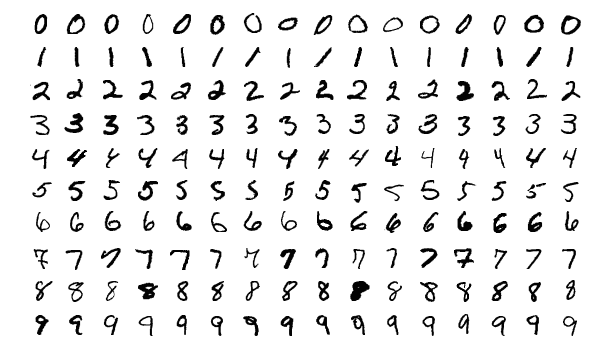

Cada imagen corresponde a una de 10 posibles categorías (los números del 0 al 9) y está almacenada en escala de grises, con un tamaño de 28x28 pixeles.

## 2.1- Lectura del set de datos

Aunque el set puede ser [descargado de Internet](http://yann.lecun.com/exdb/mnist/), su uso extendido hace que Keras haya incluido [una función](https://keras.io/api/datasets/mnist/#load_data-function) para poderlo obtener fácilmente:

In [1]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## 2.2- Exploración del set de datos

In [2]:
print('Entrenamiento:')
print(f'   x_train: {x_train.shape}')
print(f'   y_train: {y_train.shape}')
print('Prueba:')
print(f'   x_test: {x_test.shape}')
print(f'   y_test: {y_test.shape}')

Entrenamiento:
   x_train: (60000, 28, 28)
   y_train: (60000,)
Prueba:
   x_test: (10000, 28, 28)
   y_test: (10000,)


Veamos las categorías a las que pertenecen algunos ejemplos de entrenamiento:

In [5]:
import numpy as np
print(np.random.choice(y_train,10))

[1 9 0 3 7 8 7 1 1 4]


Veamos algunos ejemplos de entrenamiento

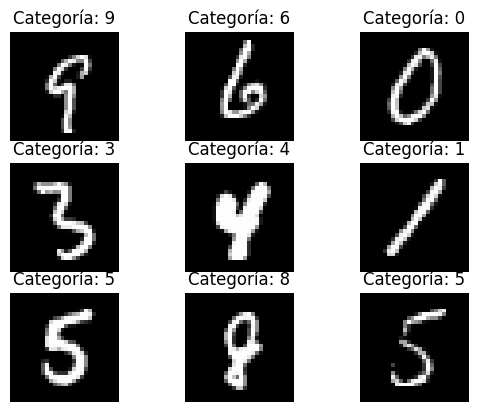

In [7]:
import matplotlib.pyplot as plt

# Seleccionar una muestra de 9 imágenes, y dibujarlas junto con
# sus respectivas categorías
idx = np.random.choice(60000,9)
fig, axes = plt.subplots(3,3)
for i, axis in enumerate(axes.flat):
  axis.imshow(x_train[idx[i],:,:].reshape(28,28), cmap='gray');
  axis.axis('off')

  titulo = f'Categoría: {y_train[idx[i]]}'
  axis.set_title(titulo)

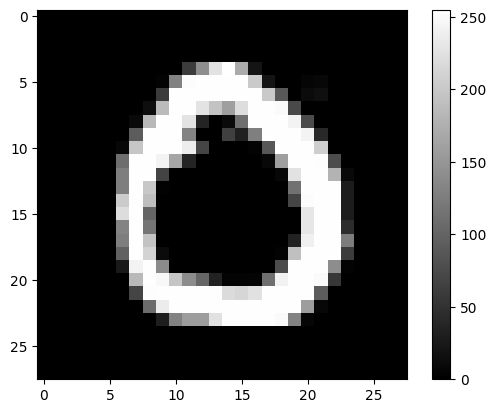

In [9]:
# Una imagen individual
idx = np.random.choice(60000,1)
fig = plt.figure()
plt.imshow(x_train[idx,:,:].reshape(28,28), cmap='gray')
plt.colorbar();


## 2.3- Normalización y reajuste del tamaño de los sets

In [10]:
print(f'x_train mínimo/máximo: {np.min(x_train)}/{np.max(x_train)} ')
x_train = x_train/255.
print(f'x_train normalizado mínimo/máximo: {np.min(x_train)}/{np.max(x_train)} ')

x_train mínimo/máximo: 0/255 
x_train normalizado mínimo/máximo: 0.0/1.0 


In [11]:
x_test = x_test/255.

In [12]:
# Cada imagen ingresada a la red debe ser de 28x28x1, y no simplemente de
# 28x28
print(f'Tamaños originales: {x_train.shape}, {x_test.shape}')
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print(f'Tamaños ajustados: {x_train.shape}, {x_test.shape}')

# Convertir cada categoría a representación one-hot
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Tamaños originales: (60000, 28, 28), (10000, 28, 28)
Tamaños ajustados: (60000, 28, 28, 1), (10000, 28, 28, 1)


# 3- Creación y entrenamiento del modelo

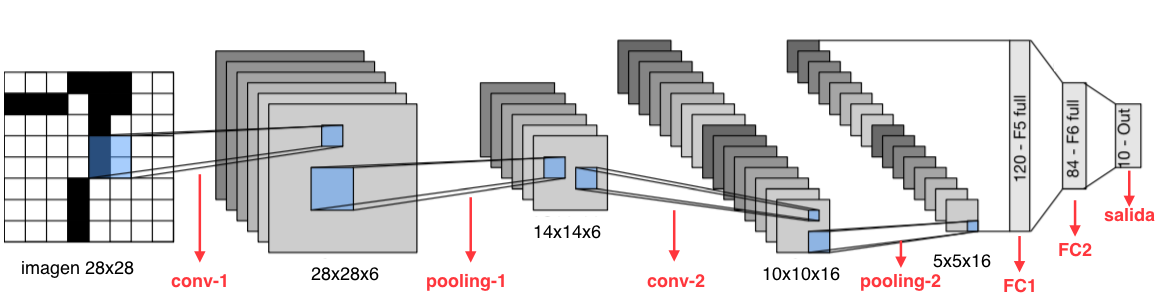

| **Capa**          | **Características**                            |
|-------------------|------------------------------------------------|
| CONV 1            | 6 filtros, 5x5x1, p=2, s=1, activación: ReLU     |
| MAX-POOLING 1     | 6 filtros, 2x2, p=0, s=2, activación: N/A      |
| CONV 2            | 16 filtros, 5x5x6, p=0, s=1, activación: ReLU    |
| MAX-POOLING 2     | 16 filtros, 2x2, p=0, s=2, activación: N/A     |
| FLATTEN           | Aplanar el volumen de la capa anterior         |
| F.C. 1            | 120 neuronas, activación: ReLU                 |
| FULLY CONNECTED 2 | 84 neuronas, activación: ReLU                  |
| SALIDA            | 10 categorías, activación: softmax             |

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

lenet = Sequential()

lenet.add(Input(shape=(28, 28, 1)))

# conv-1 (padding='same': salida/entrada con el mismo alto/ancho)
lenet.add(Conv2D(filters=6, kernel_size=(5,5), padding='same',activation='relu', name='conv_1'))

# pooling-1
lenet.add(MaxPooling2D(pool_size=(2,2), strides=2, name='pooling-1'))

# conv-2 (padding='valid': no hay padding (por defecto)
lenet.add(Conv2D(filters=16, kernel_size=(5,5), activation='relu', name='conv-2'))

# pooling-2
lenet.add(MaxPooling2D(pool_size=(2,2), strides=2, name='pooling-2'))

# Aplanar, FC1, FC2 y salida
lenet.add(Flatten(name='Flatten'))
lenet.add(Dense(120,activation='relu', name='FC1'))
lenet.add(Dense(84,activation='relu', name='FC2'))
lenet.add(Dense(10,activation='softmax', name='output'))

lenet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling-1 (MaxPooling2D)        │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv-2 (Conv2D)                 │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling-2 (MaxPooling2D)        │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compilación
sgd = SGD(learning_rate=0.1)
lenet.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

# Entrenamiento
nepochs = 20
tam_lote = 128
historia=lenet.fit(x_train,y_train,epochs=nepochs,batch_size=tam_lote, validation_data=(x_test,y_test), verbose=1)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8770 - loss: 0.3817 - val_accuracy: 0.9695 - val_loss: 0.0980
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9702 - loss: 0.0943 - val_accuracy: 0.9783 - val_loss: 0.0695
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9781 - loss: 0.0682 - val_accuracy: 0.9822 - val_loss: 0.0584
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9832 - loss: 0.0536 - val_accuracy: 0.9831 - val_loss: 0.0518
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9860 - loss: 0.0438 - val_accuracy: 0.9835 - val_loss: 0.0488
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9884 - loss: 0.0366 - val_accuracy: 0.9841 - val_loss: 0.0487
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9846 - val_loss: 0.0483
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9918 - loss: 0.0263 - val_accuracy: 0

#4 - Resultados del entrenamiento

Veamos en detalle el comportamiento de la Red Convolucional entrenada:

In [17]:
import matplotlib.pyplot as plt

def graficar(historia):
  plt.figure(figsize=(15,5))

  loss = historia.history['loss']
  accuracy = historia.history['accuracy']
  test_loss = historia.history['val_loss']
  test_accuracy = historia.history['val_accuracy']
  epochs = historia.epoch

  plt.subplot(121)
  plt.plot(epochs,loss,label='train_loss')
  plt.plot(epochs,test_loss,'b--',label='test_loss')
  plt.legend()

  plt.subplot(122)
  plt.plot(epochs,accuracy,label='train_acc')
  plt.plot(epochs,test_accuracy,'b--',label='test_acc')
  plt.legend()

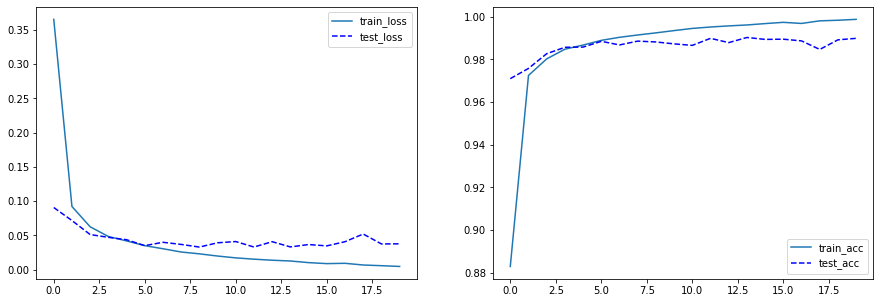

In [ ]:
graficar(historia)